# Important imports

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import random


SEED = 96
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


df = pd.read_csv("spam.csv", sep=",", encoding='latin-1')

# Preprocessing Data
* one hot encoding
* dropping unnecessary labels

In [4]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)
df.rename(columns={"v1":"label", "v2": "text"}, inplace=True)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df.head(5))

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


## Removing all stop words from text
they create random noice and do not carry any information

In [5]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word.lower() not in stop_words])

df['text_clean'] = df['text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Splitting data into train and test
we dont want to affect testing data by any preprocessing

In [6]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Encoding all emails as numbers in data frame
* Adapting the data frame for vocabulary from emails
* lowercase and without punctuation
* splitting on whitespace
* outputing int

In [7]:
VOCAB_SIZE = 1000
encoder = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=100
)

encoder.adapt(train_df['text'])
encoded_example = encoder(train_df['text']).numpy()
print(encoded_example)

[[ 40  24   9 ...   0   0   0]
 [807  15   1 ...   0   0   0]
 [110  88   1 ...   0   0   0]
 ...
 [  1   1 252 ...   0   0   0]
 [773   1   1 ...   0   0   0]
 [  9 147  23 ...   0   0   0]]


## Dropping any missing values
missing cells could be caused by improper data or inputs e.g. only having stop words

In [8]:
train_df = train_df.dropna(subset=['text'])
train_df = train_df[train_df['text'].str.strip() != ""]

## Checking class imbalance
class imbalance could lean model into one class

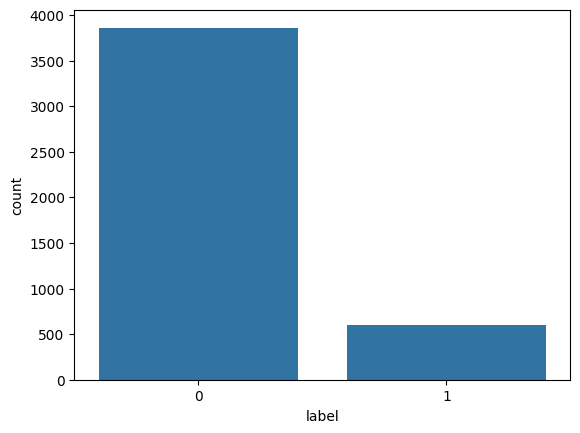

In [9]:
sns.countplot(x='label', data=train_df)
plt.show()

## Solving class imbalance
Downsampling majority class

In [10]:
df_majority = train_df[train_df['label'] == 0]
df_minority = train_df[train_df['label'] == 1]

df_majority_downsampled = df_majority.sample(n=len(df_minority))
train_df = pd.concat([df_majority_downsampled, df_minority])
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

## Displaying assurance of solving class imbalance

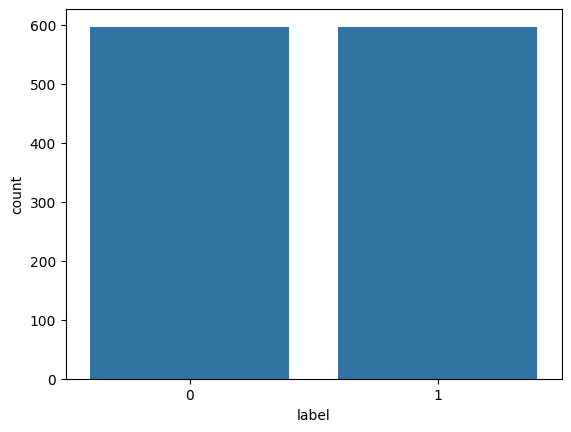

In [11]:
sns.countplot(x='label', data=train_df)
plt.show()

# Model
## Model Architecture
* encoding inputs
* input layer of 1000 columns (words) from each email
* output layer of 100 dimensions for each word
* skipping zeros
* Simple RNN with 10 neurons
  - activation function is sigmoid
  - output is either spam or ham


In [12]:
model = tf.keras.Sequential([
    encoder,
    layers.Embedding(
        input_dim=1000,
        output_dim=100,
        mask_zero=True
    ),
    layers.SimpleRNN(10),
    layers.Dense(1, activation='sigmoid'),
])

## Parameters chosen for the model
* adamW as the optimizer for more better generalization and good NLP
* binary cross entropy for loss function because of good measure between two probability distributions
* accuracy as metric because it is the most important measure

In [13]:
model.compile(
    optimizer='adamw',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Training
* epochs and batch_size chosen from past experience and for good computational efficiency

In [14]:
history = model.fit(
    tf.convert_to_tensor(train_df['text'].values, dtype=tf.string),
    train_df['label'].values.astype('float32'),
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.7079 - loss: 0.6125 - val_accuracy: 0.8745 - val_loss: 0.5016
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9309 - loss: 0.3817 - val_accuracy: 0.8996 - val_loss: 0.3685
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9707 - loss: 0.2434 - val_accuracy: 0.9163 - val_loss: 0.2885
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9791 - loss: 0.1599 - val_accuracy: 0.9372 - val_loss: 0.2273
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9885 - loss: 0.1067 - val_accuracy: 0.9331 - val_loss: 0.2072
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9916 - loss: 0.0760 - val_accuracy: 0.9331 - val_loss: 0.1962
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9927 - loss: 0.0573 - val_accuracy: 0.9414 - val_loss: 0.1931
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9948 - loss: 0.0474 - val_accuracy: 0.9498 - v

# Evaluation
## Testing Model

checking accuracy and loss of the model on test data

In [15]:
x_test = tf.constant(test_df['text'].tolist())
y_test = tf.constant(test_df['label'].tolist())


print("Evaluating on test data...")
loss, accuracy = model.evaluate(x_test, y_test)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating on test data...
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9516 - loss: 0.1503

Test Loss: 0.1503
Test Accuracy: 0.9516


# Plotting
## Confusion matrix
Displaying loss and accuracy over time on training and test data

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


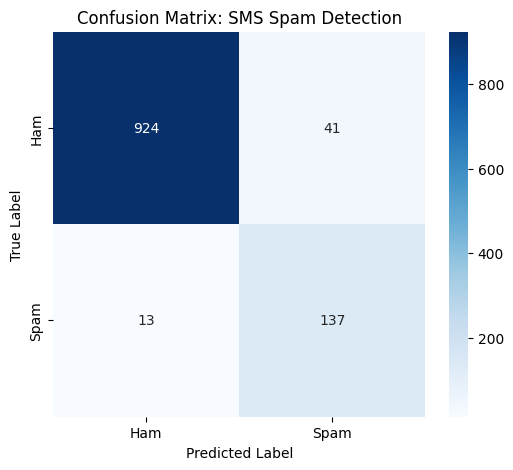

In [16]:
y_pred_probs = model.predict(x_test)
y_pred_labels = (y_pred_probs > 0.5).astype(int)
cm = confusion_matrix(test_df['label'], y_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: SMS Spam Detection')
plt.show()

## Loss and Accuracy
Displaying loss and accuracy over time on training and test data

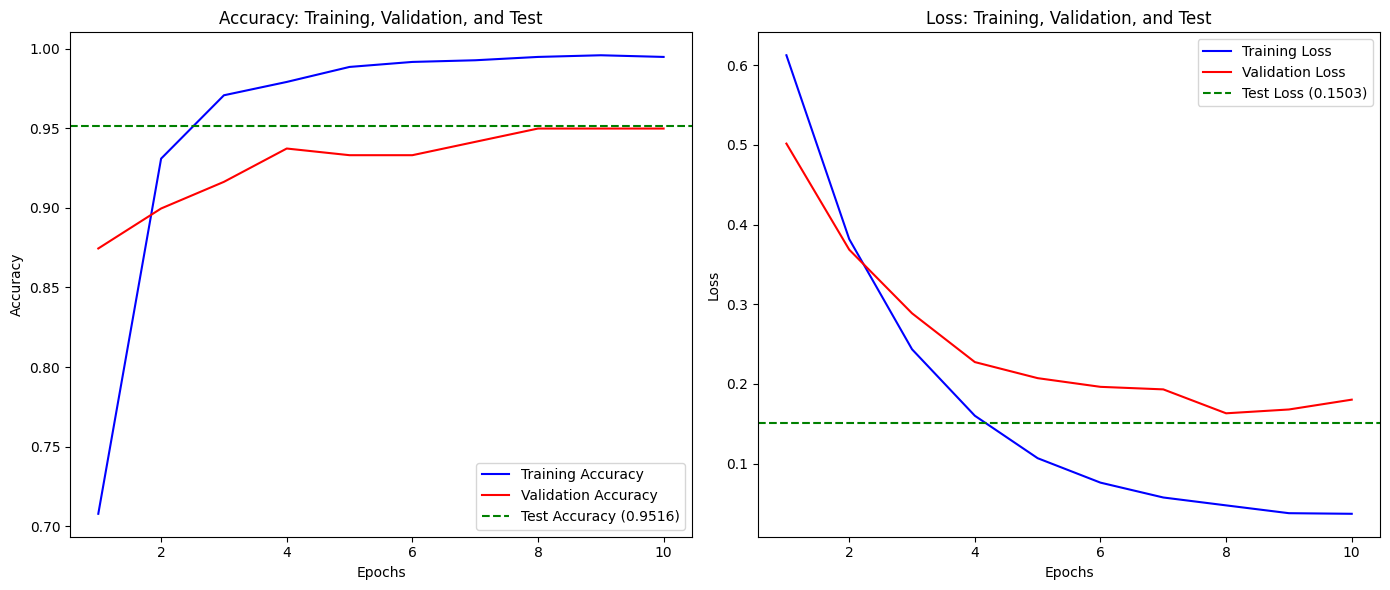

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
plt.axhline(y=test_accuracy, color='green', linestyle='--', label=f'Test Accuracy ({test_accuracy:.4f})')
plt.title('Accuracy: Training, Validation, and Test')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.axhline(y=test_loss, color='green', linestyle='--', label=f'Test Loss ({test_loss:.4f})')
plt.title('Loss: Training, Validation, and Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()